# Intitial EDA

In [6]:
import pandas as pd 
import duckdb 

df = pd.read_csv("../data_files/alvsjo_data_raw.csv")
df

,Namn,Typ,Kategori,Gata,Nr,Lat,Lon
0,Marino,restaurant,Restaurang & Snabbmat,Klubbacken,51,59.305325,17.963290
1,Hemköp Stockholm Älvsjö,supermarket,Matbutik,Sjättenovembervägen,208,59.278752,18.002280
2,OKQ8,fuel,Bensinmack,NaN,NaN,59.294435,18.002588
3,Circle K,fuel,Bensinmack,NaN,NaN,59.299954,18.012147
4,McDonald's,fast_food,Restaurang & Snabbmat,NaN,NaN,59.293074,18.001211
...,...,...,...,...,...,...,...
540,Lekplats,playground,Lekplats,NaN,NaN,59.303276,18.016878
541,Lekplats,playground,Lekplats,NaN,NaN,59.299426,18.001098
542,Lekplats,playground,Lekplats,NaN,NaN,59.291422,17.980889
543,Lekplats,playground,Lekplats,NaN,NaN,59.282429,17.975122


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Namn      545 non-null    str    
 1   Typ       545 non-null    str    
 2   Kategori  544 non-null    str    
 3   Gata      115 non-null    str    
 4   Nr        110 non-null    str    
 5   Lat       545 non-null    float64
 6   Lon       545 non-null    float64
dtypes: float64(2), str(5)
memory usage: 29.9 KB


In [8]:
df.dtypes 

# This gives the insight on the data types - and also makes me question why  nr  is str? 

Namn            str
Typ             str
Kategori        str
Gata            str
Nr              str
Lat         float64
Lon         float64
dtype: object

In [9]:
df.describe()

,Lat,Lon
count,545.000000,545.000000
mean,59.296407,17.996263
std,0.011657,0.022851
min,59.264781,17.943174
25%,59.286200,17.976784
50%,59.298668,18.000730
75%,59.305760,18.012823
max,59.316601,18.037330


In [10]:
# T stands for transpose: rows  <-> cols (switch places)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Lat,545.0,59.296407,0.011657,59.264781,59.286200,59.298668,59.305760,59.316601
Lon,545.0,17.996263,0.022851,17.943174,17.976784,18.000730,18.012823,18.037330


### Rows & Columns

In [11]:
df.columns

Index(['Namn', 'Typ', 'Kategori', 'Gata', 'Nr', 'Lat', 'Lon'], dtype='str')

In [12]:
len(df.columns)

7

In [13]:
df.index

RangeIndex(start=0, stop=545, step=1)

In [14]:
#Adding 1 because it doesnt count row 0 
len(df.index) + 1 

546

### Check for missing or Null values

In [15]:
duckdb.sql("""--sql 
    select *
    from df 
    where 
        namn IS NULL OR 
        typ IS NULL OR
        kategori IS NULL OR
        gata IS NULL OR
        nr IS NULL OR 
        lat IS NULL OR
        lon IS NULL
           
""").df()

,Namn,Typ,Kategori,Gata,Nr,Lat,Lon
0,OKQ8,fuel,Bensinmack,NaN,NaN,59.294435,18.002588
1,Circle K,fuel,Bensinmack,NaN,NaN,59.299954,18.012147
2,McDonald's,fast_food,Restaurang & Snabbmat,NaN,NaN,59.293074,18.001211
3,Sushi Bar,restaurant,Restaurang & Snabbmat,NaN,NaN,59.292424,17.967934
4,Lekplats,playground,Lekplats,NaN,NaN,59.264781,17.984072
...,...,...,...,...,...,...,...
431,Lekplats,playground,Lekplats,NaN,NaN,59.303276,18.016878
432,Lekplats,playground,Lekplats,NaN,NaN,59.299426,18.001098
433,Lekplats,playground,Lekplats,NaN,NaN,59.291422,17.980889
434,Lekplats,playground,Lekplats,NaN,NaN,59.282429,17.975122


In [16]:


duckdb.sql("""--sql 
    SELECT
        COUNT(*) - COUNT(namn)     AS namn_nulls,
        COUNT(*) - COUNT(typ)      AS typ_nulls,
        COUNT(*) - COUNT(kategori) AS kategori_nulls,
        COUNT(*) - COUNT(gata)     AS gata_nulls,
        COUNT(*) - COUNT(nr)       AS nr_nulls,
        COUNT(*) - COUNT(lat)      AS lat_nulls,
        COUNT(*) - COUNT(lon)      AS lon_nulls
    FROM df
""").df()

,namn_nulls,typ_nulls,kategori_nulls,gata_nulls,nr_nulls,lat_nulls,lon_nulls
0,0,0,1,430,435,0,0


### Unique values in typ & kategori

In [17]:
len(df.Kategori.unique())

15

In [18]:
len(df.Typ.unique())

17

In [19]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
540    False
541    False
542    False
543    False
544    False
Length: 545, dtype: bool

In [20]:
print(f"Antal dubbletter: {df.duplicated().sum()}")


Antal dubbletter: 0


### Check categories 

In [21]:
df['Kategori'].value_counts()

Kategori
Restaurang & Snabbmat    192
Lekplats                 186
Kafé                      40
Gym/Utomhusgym            36
Matbutik                  26
Tandläkare                15
Apotek                    11
Bensinmack                 9
Trafikskola                8
Vårdcentral                7
Bibliotek                  6
Systembolag                4
Biograf                    3
Fysioterapeut              1
Name: count, dtype: int64

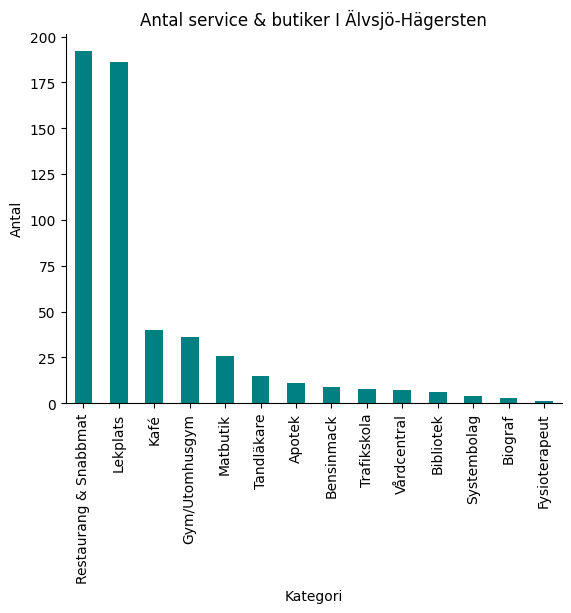

In [22]:
ax = df['Kategori'].value_counts().plot(
    kind='bar', color='teal', edgecolor='none')
ax.set_title("Antal service & butiker I Älvsjö-Hägersten")
ax.set_ylabel("Antal")
ax.set_xlabel("Kategori")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)  

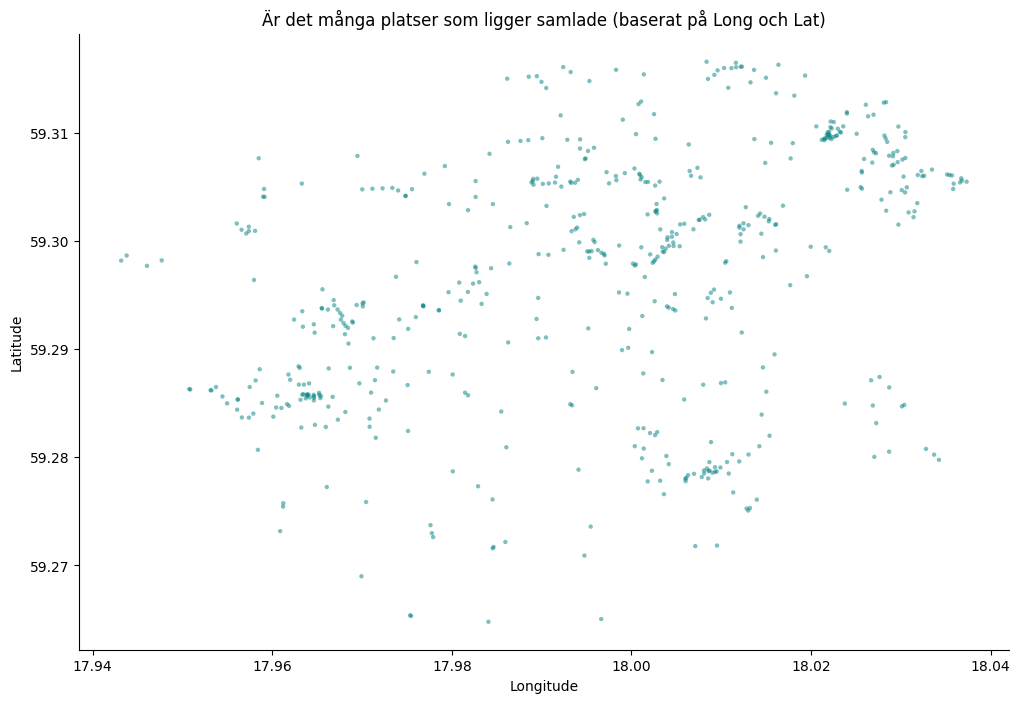

In [38]:
ax = df.plot.scatter(x='Lon', y='Lat', alpha=0.5, s=10,
                     figsize=(12, 8), color='teal', edgecolor='none')

ax.set_title("Är det många platser som ligger samlade (baserat på Long och Lat)")
ax.set_ylabel("Latitude")
ax.set_xlabel("Longitude")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
